In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.model_selection import RandomizedSearchCV, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    recall_score,
    f1_score
)






In [4]:
#configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
sns.set_theme(style='darkgrid')

RANDOM_STATE = 42
CSV_PATH = r"C:\Users\user\Downloads\Machine-Learning-Project-Heart-Disease-Risk-Prediction\dataset\heart.csv"
TARGET_COL = 'target'



**Loading Data**

In [5]:
df = pd.read_csv(CSV_PATH)
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [6]:
# EXPLORATORY DATA ANALYSIS (EDA)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [28]:
numeric_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    'ca'
]

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal',
    'target'
]

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


In [29]:
#checking for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [30]:
#checking for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

age
58    68
57    57
54    53
59    46
52    43
56    39
51    39
62    37
60    37
44    36
Name: count, dtype: int64
sex
1    713
0    312
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
Name: count, dtype: int64
chol
204    21
234    21
197    19
212    18
254    17
269    16
240    14
282    14
177    14
226    13
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1    513
0    497
2     15
Name: count, dtype: int64
thalach
162    35
160    31
163    29
152    28
173    28
132    26
144    26
125    25
150    25
143    23
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
oldpeak
0.000    329
1.200     58
1.000     51
0.600     47
0.800     44
1.400     44
1.600     37
0.200     37
1.800     36
2.000     32
Name: count, dtype: int64
slope
1    482
2    469
0     74
N

In [31]:
#checking for duplicates
duplicate_mask = df.duplicated()
print("Number of duplicate rows:", duplicate_mask.sum())

Number of duplicate rows: 723


In [32]:
#TARGET DISTRIBUTION
print(df[TARGET_COL].value_counts())
print("-"*50)
print(df[TARGET_COL].value_counts(normalize=True))

target
1    526
0    499
Name: count, dtype: int64
--------------------------------------------------
target
1   0.513
0   0.487
Name: proportion, dtype: float64


In [38]:
df[numeric_features].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000
mean,54.434,131.612,246.000,149.114,1.072,0.754
std,9.072,17.517,51.593,23.006,1.175,1.031
min,29.000,94.000,126.000,71.000,0.000,0.000
25%,48.000,120.000,211.000,132.000,0.000,0.000
50%,56.000,130.000,240.000,152.000,0.800,0.000
75%,61.000,140.000,275.000,166.000,1.800,1.000
max,77.000,200.000,564.000,202.000,6.200,4.000


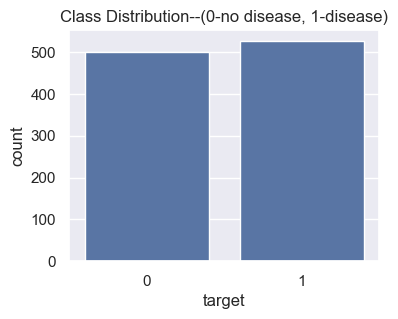

In [39]:
#VISUALIZING TARGET DISTRIBUTION
plt.figure(figsize=(4,3))
sns.countplot(x=TARGET_COL, data=df)
plt.title("Class Distribution--(0-no disease, 1-disease)")
plt.show()

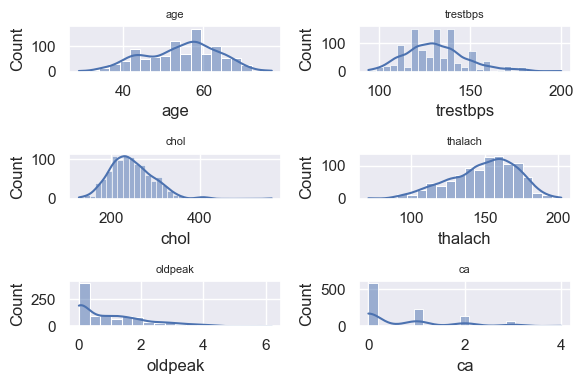

In [40]:
#histogram distribution of numeric features
fig, axes = plt.subplots(3, 2, figsize=(6,4))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

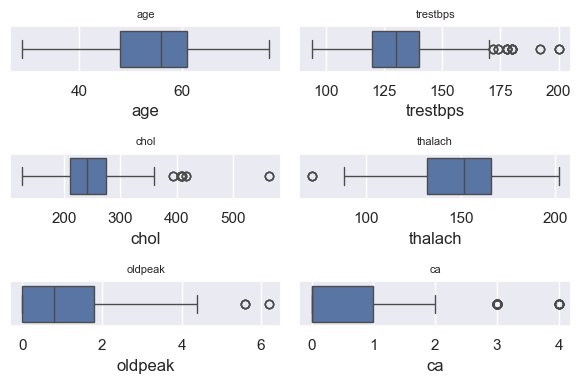

In [41]:
#outliers analysis using boxplots
fig, axes = plt.subplots(3, 2, figsize=(6,4))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

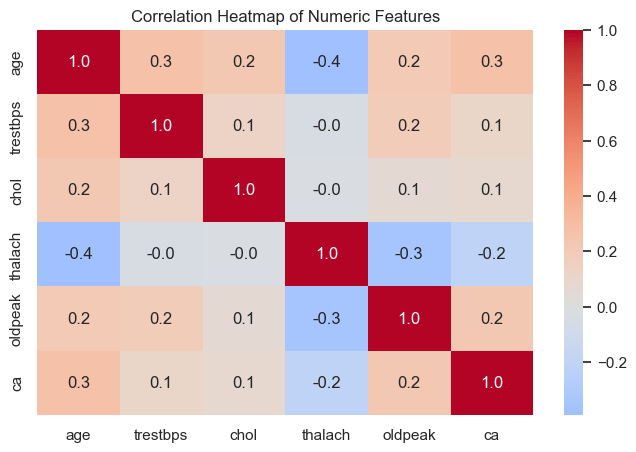

In [42]:
#identifying presence of highly correlated columns & feature relationships
plt.figure(figsize=(8,5))
sns.heatmap(df[numeric_features].corr(),
          annot=True,
          cmap='coolwarm',
          fmt=".1f",
          center=0
          )

plt.title("Correlation Heatmap of Numeric Features")
plt.show()


#as we can see below, no highly correlated features are present, so we can keep all numeric features for modeling

**Data Preprocessing**

In [43]:
#separating X and y
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

#create a signature for each feature row - to prevent duplicates flow into the test set
row_signature = pd.util.hash_pandas_object(X, index=False)

In [44]:
#split data into train and test sets using GroupShuffleSplit
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state= 42
)

train_idx, test_idx = next(gss.split(X, y, groups=row_signature))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (869, 13)
Test set shape: (156, 13)


**Baseline Model - Logistic Regression**

In [45]:
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=RANDOM_STATE))
])

In [46]:
#training the base pipeline
base_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

In [55]:
#reusable evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    #results
    print(f"{model_name} - Training Accuracy: {100 * train_acc:.2f}%")
    print(f"{model_name} - Test Accuracy: {100 * test_acc:.2f}%\n")

    print("-"*50)

    print("Training Classification Report")
    print(classification_report(y_train, y_train_pred))

    print("Test Classification Report")
    print(classification_report(y_test, y_test_pred))

    

In [56]:
evaluate_model(base_pipe,
             X_train,
             y_train,
             X_test,
             y_test, 
             model_name="Base Logistic Regression Pipeline")

Base Logistic Regression Pipeline - Training Accuracy: 84.23%
Base Logistic Regression Pipeline - Test Accuracy: 83.33%

--------------------------------------------------
Training Classification Report
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       430
           1       0.81      0.89      0.85       439

    accuracy                           0.84       869
   macro avg       0.85      0.84      0.84       869
weighted avg       0.85      0.84      0.84       869

Test Classification Report
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156



**MODEL SELECTION**

In [57]:
#models to evaluate
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier()
}

In [59]:
groups = pd.util.hash_pandas_object(X_train, index=False)

k=5
cv = StratifiedGroupKFold(n_splits=k, shuffle = True, random_state = RANDOM_STATE)

In [60]:
for name, model in models.items():

    recall_scores = []
    f1_scores = []

    for train_idx, test_idx in cv.split(X_train, y_train, groups=groups):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        pipe.fit(X_tr, y_tr)
        y_te_pred = pipe.predict(X_te)

        recall_scores.append(round(recall_score(y_te, y_te_pred),2))
        f1_scores.append(round(f1_score(y_te, y_te_pred),2))

    print("Model Name:", name)
    print("Recall Values:", recall_scores)
    print("F1 Scores:", f1_scores)
    print("-"*50)
    print("\nCV Recall Mean:", round(float(np.mean(recall_scores)),4))
    print("CV F1 Mean:", round(float(np.mean(f1_scores)),4))


Model Name: Logistic Regression
Recall Values: [0.9, 0.75, 0.93, 0.89, 0.82]
F1 Scores: [0.87, 0.75, 0.91, 0.82, 0.75]
--------------------------------------------------

CV Recall Mean: 0.858
CV F1 Mean: 0.82
Model Name: Random Forest
Recall Values: [0.93, 0.82, 0.9, 0.92, 0.82]
F1 Scores: [0.88, 0.81, 0.87, 0.87, 0.75]
--------------------------------------------------

CV Recall Mean: 0.878
CV F1 Mean: 0.836
Model Name: Support Vector Machine
Recall Values: [0.79, 0.72, 0.82, 0.96, 0.72]
F1 Scores: [0.76, 0.76, 0.84, 0.83, 0.69]
--------------------------------------------------

CV Recall Mean: 0.802
CV F1 Mean: 0.776
Model Name: XGBoost
Recall Values: [0.82, 0.72, 0.9, 0.97, 0.82]
F1 Scores: [0.79, 0.78, 0.86, 0.87, 0.72]
--------------------------------------------------

CV Recall Mean: 0.846
CV F1 Mean: 0.804


**RandomForestClassifier** provides the highest performance

In [61]:
rfc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

In [62]:
#parameter distribution
param_dist = {
    'model__n_estimators': randint(400, 1200),
    'model__max_depth': [3,4,5,6],
    'model__min_samples_split': randint(10, 40),
    'model__min_samples_leaf': randint(4, 20),
    'model__max_features': [0.25, 0.35, 0.5, "sqrt"],
    'model__bootstrap': [True],
    'model__max_samples': uniform(0.6, 0.35),
    'model__ccp_alpha': uniform(0.0, 0.02)
}

In [63]:
#randomized search
random_search = RandomizedSearchCV(
    estimator=rfc_pipe,
    param_distributions=param_dist,
    n_iter=60,
    cv=cv,
    scoring='f1_macro',
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [64]:
#randomized search cv
random_search.fit(X_train, y_train, groups=groups)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....0026D37653250>, 'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation str

In [65]:
print("Hyperparameter Tuning Results:")
print("Best parameters:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)

Hyperparameter Tuning Results:
Best parameters: {'model__bootstrap': True, 'model__ccp_alpha': np.float64(0.00176985004103839), 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__max_samples': np.float64(0.6158295511186883), 'model__min_samples_leaf': 11, 'model__min_samples_split': 30, 'model__n_estimators': 1119}
Best cross-validation score: 0.852893791963765


**Retraining with Best Parameters**

In [68]:
rfc_best = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            n_estimators=random_search.best_params_['model__n_estimators'],
            max_depth=random_search.best_params_['model__max_depth'],
            min_samples_split=random_search.best_params_['model__min_samples_split'],
            min_samples_leaf=random_search.best_params_['model__min_samples_leaf'],
            max_features=random_search.best_params_['model__max_features'],
            bootstrap=random_search.best_params_['model__bootstrap'],
            max_samples=random_search.best_params_['model__max_samples'],
            ccp_alpha=random_search.best_params_['model__ccp_alpha']
        ))
    ]
)

In [69]:
#train the best model
rfc_best.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1119
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30


**Model Evaluation**

In [71]:
evaluate_model(
    rfc_best,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="Random Forest-Best Model"
)

Random Forest-Best Model - Training Accuracy: 89.76%
Random Forest-Best Model - Test Accuracy: 81.41%

--------------------------------------------------
Training Classification Report
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       430
           1       0.87      0.94      0.90       439

    accuracy                           0.90       869
   macro avg       0.90      0.90      0.90       869
weighted avg       0.90      0.90      0.90       869

Test Classification Report
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        69
           1       0.80      0.90      0.84        87

    accuracy                           0.81       156
   macro avg       0.82      0.80      0.81       156
weighted avg       0.82      0.81      0.81       156



**Build a Prediction System**

In [72]:
import pandas as pd

def predict_heart_disease(input_features):
    
    #create a dataset with the correct column order
    input_df = pd.DataFrame([input_features], columns=X_train.columns)

    #class prediction
    prediction = rfc_best.predict(input_df)[0]
    
    #probability prediction
    probability = rfc_best.predict_proba(input_df)[0][1]

    #output
    if prediction == 1:
        return f"High risk of heart disease with a probability of {probability:.2f}"
    else:
        return f"Low risk of heart disease with a probability of {1-probability:.2f}"

    return prediction, probability


In [73]:
y_test[y_test == 1].head()

24    1
38    1
57    1
68    1
84    1
Name: target, dtype: int64

In [74]:
y_test[y_test == 0].head()

4     0
8     0
17    0
43    0
53    0
Name: target, dtype: int64

In [75]:
#sample unknown data point - access from test data index
test_1 = X_test.loc[24].tolist()
print(test_1)

[42.0, 0.0, 2.0, 120.0, 209.0, 0.0, 1.0, 173.0, 0.0, 0.0, 1.0, 0.0, 2.0]


In [76]:
predict_heart_disease(test_1)

'High risk of heart disease with a probability of 0.95'

In [77]:
#sample unknown data point - access from test data index
test_2 = X_test.loc[4].tolist()
print(test_2)

[62.0, 0.0, 0.0, 138.0, 294.0, 1.0, 1.0, 106.0, 0.0, 1.9, 1.0, 3.0, 2.0]


In [78]:
predict_heart_disease(test_2)

'Low risk of heart disease with a probability of 0.73'